In [10]:
%pip install -r requirements.txt
 
from dotenv import load_dotenv
import os
import requests
import random
from datetime import datetime, timedelta
from collections import defaultdict
import matplotlib.pyplot as plt

load_dotenv()
token = os.getenv("USER_TOKEN")
random.seed(42)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Mock data - 20 posts

In [11]:
posts = []
for i in range(20):
    date = datetime.now() - timedelta(days=random.randint(1, 90))
    posts.append({
        "id": f"post_{i+1}",
        "message": f"This is test post number {i+1}",
        "created_time": date.strftime("%Y-%m-%dT%H:%M:%S"),
        "day_of_week": date.strftime("%A"),
        "likes": random.randint(0, 500),
        "comments": random.randint(0, 100)
    })

print(f"Total posts loaded: {len(posts)}")

Total posts loaded: 20


## Top 3 posts by likes

In [12]:
top_3 = sorted(posts, key=lambda x: x["likes"], reverse=True)[:3]
print("\nTop 3 posts by likes:")
for i, post in enumerate(top_3, 1):
    print(f"{i}. {post['message']} - {post['likes']} likes, {post['comments']} comments")


Top 3 posts by likes:
1. This is test post number 15 - 490 likes, 97 comments
2. This is test post number 12 - 414 likes, 0 comments
3. This is test post number 4 - 379 likes, 69 comments


In [13]:
day_likes = defaultdict(list)
for post in posts:
    day_likes[post["day_of_week"]].append(post["likes"])

day_avg = {day: sum(likes)/len(likes) for day, likes in day_likes.items()}
day_avg_sorted = sorted(day_avg.items(), key=lambda x: x[1], reverse=True)

print("\nAverage likes by day of week:")
for day, avg in day_avg_sorted:
    print(f"{day}: {avg:.1f} likes")


Average likes by day of week:
Saturday: 377.0 likes
Sunday: 344.0 likes
Wednesday: 253.8 likes
Thursday: 238.3 likes
Tuesday: 195.2 likes
Friday: 185.0 likes
Monday: 97.0 likes


## Average likes by day of week

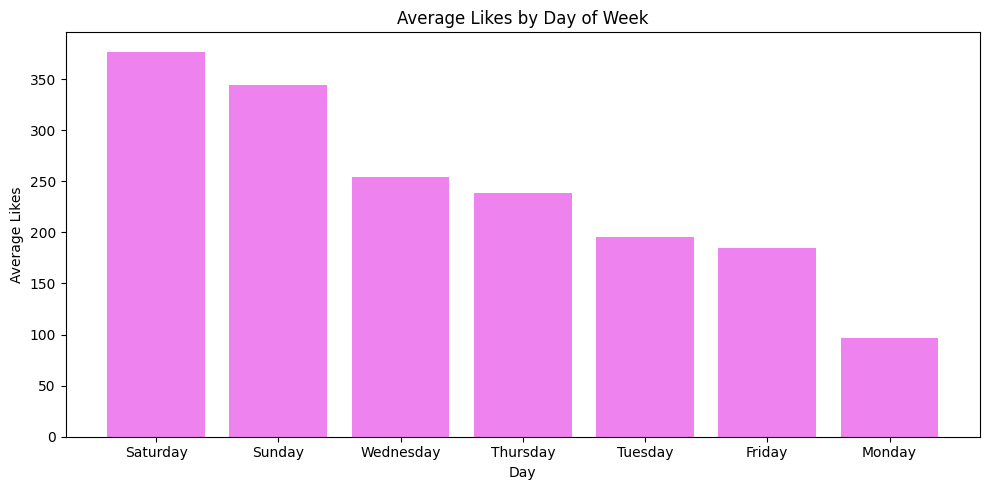

In [14]:
days = [d[0] for d in day_avg_sorted]
avgs = [d[1] for d in day_avg_sorted]

plt.figure(figsize=(10,5))
plt.bar(days, avgs, color='violet')
plt.title('Average Likes by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average Likes')
plt.tight_layout()
plt.savefig('engagement_chart.png')
plt.show()

## Summary

In [15]:
total_likes = sum(p["likes"] for p in posts)
total_comments = sum(p["comments"] for p in posts)
best_day = day_avg_sorted[0][0]
worst_day = day_avg_sorted[-1][0]

print("\nOverall Analysis:")
print(f"Total posts: {len(posts)}")
print(f"Total likes: {total_likes}")
print(f"Total comments: {total_comments}")
print(f"Average likes/post: {total_likes/len(posts):.1f}")
print(f"Average comments/post: {total_comments/len(posts):.1f}")
print(f"Best performing day: {best_day}")
print(f"Worst performing day: {worst_day}")
print(f"\nConclusion: Posting on {best_day} generates the most engagement.")


Overall Analysis:
Total posts: 20
Total likes: 4510
Total comments: 889
Average likes/post: 225.5
Average comments/post: 44.5
Best performing day: Saturday
Worst performing day: Monday

Conclusion: Posting on Saturday generates the most engagement.
